# QED-C Application-Oriented Benchmarks - MQT Bench Example
The notebook demonstrates modularized problem generation, execution, and analysis, where the problem generation is done using MQT Bench. 

The list of MQT Bench algorithmic benchmarks can be found at the following website: https://mqt.readthedocs.io/projects/bench/en/latest/benchmark_selection.html.

Configure and run the cell below with the desired execution settings, then proceed to run the remaining cells.

In [1]:
benchmark_name = 'wstate'
min_qubits=2
max_qubits=8
skip_qubits=1
max_circuits=3
num_shots=1000

## Part 1: Problem Generation with MQT Bench
The code below grabs __circuits__ from MQT Bench from __min_qubits__ to __max_qubits__ using __skip_qubits__ and __max_circuits__. 

Note that we do not get any metadata from MQT Bench; we __initialize metadata as an empty dictionary__ and later use the QED-C metrics module to compute additional metrics.

In [2]:
from mqt.bench import get_benchmark, BenchmarkLevel

def get_mqt_circuits(
    benchmark_name:str, 
    min_qubits:int, 
    max_qubits:int, 
    skip_qubits:int, 
    max_circuits:int
    ):
    circuits = {}
    for n_qubits in range(min_qubits, max_qubits+1, skip_qubits):
        circuits_n_qubits = {}
        for idx in range(1, max_circuits+1):
            circuits_n_qubits[str(idx)] = get_benchmark(benchmark=benchmark_name, level=BenchmarkLevel.ALG, circuit_size=n_qubits)
        circuits[str(n_qubits)] = circuits_n_qubits
    return circuits

In [3]:
# Using the above function to grab circuits. 
circuits = get_mqt_circuits(benchmark_name, min_qubits, max_qubits, skip_qubits, max_circuits)

# No metadata from MQT Bench.
metadata = {}

In [4]:
print(f"\nCircuits:\n{circuits}")
print(f"\nMetadata: \n{metadata}") # 


Circuits:
{'2': {'1': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10c8bb560>, '2': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10b07ad20>, '3': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x105f1e120>}, '3': {'1': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x105f1fc80>, '2': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x105f45040>, '3': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x105f451c0>}, '4': {'1': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x105f44aa0>, '2': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10c810ef0>, '3': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x105f44ad0>}, '5': {'1': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10c92e9f0>, '2': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10c92eb40>, '3': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10c92ec30>}, '6': {'1': <qiskit.circuit.quantumcircuit.QuantumCircuit obj

## Part 2: Execution

Now that we have the Qiskit circuits, we are free to run them using any execution framework that supports Qiskit!

### Preprocessing and Additional Metrics
We first convert the _circuits_ dictionary into a flat list; additionally, we choose to compute additional metrics and store them in the metrics module.

In [5]:
from _common import metrics
from _common.qiskit import execute as ex

# Remove the subtitle key for iterating purposes.
metadata.pop("subtitle", None)

# Copy any metadata from creation (i.e. create_time). This can be excluded if it's not of interest.
metrics.circuit_metrics = metadata

# Create a flat list of circuits.
circuit_identifiers = []
flat_circuits = []
for num_qubits in circuits.keys():
    for circuit_id in circuits[num_qubits].keys():
        circuit_identifiers.append((num_qubits, circuit_id))
        flat_circuits.append(circuits[num_qubits][circuit_id])

        # Optionally compute additional circuit properties (depth, etc.) and store to metrics.
        ex.compute_and_store_circuit_info(
            circuits[num_qubits][circuit_id],
            str(num_qubits),
            str(circuit_id),
            do_transpile_metrics=True,
            use_normalized_depth=True,
        )

print(f"Flat Circuits ({len(flat_circuits)}): \n{flat_circuits}\n")
print(f"Additional Metrics: \n{metrics.circuit_metrics}")

Flat Circuits (21): 
[<qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10c8bb560>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10b07ad20>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x105f1e120>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x105f1fc80>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x105f45040>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x105f451c0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x105f44aa0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10c810ef0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x105f44ad0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10c92e9f0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10c92eb40>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10c92ec30>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10c92ecc0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x10c92ede0>

## Running Circuits

We can choose to run on any execution platform that supports Qiskit circuits; for example, running through qBraid, _pyGSTi_, or a custom platform. 

For the sake of this demonstration, we will execute through a simple simulator.  

In [6]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator

sim = Aer.get_backend("aer_simulator")
tqc = transpile(flat_circuits, sim)
result = sim.run(tqc, shots=num_shots).result()

In [7]:
print(f"Results ({len(result.get_counts())}):")
print(result.get_counts())

Results (21):
[{'10': 492, '01': 508}, {'10': 493, '01': 507}, {'10': 516, '01': 484}, {'100': 356, '010': 333, '001': 311}, {'100': 356, '010': 321, '001': 323}, {'100': 341, '001': 335, '010': 324}, {'0001': 247, '0100': 246, '0010': 260, '1000': 247}, {'0001': 247, '1000': 258, '0010': 261, '0100': 234}, {'0100': 264, '0001': 251, '0010': 230, '1000': 255}, {'00001': 183, '01000': 195, '00010': 188, '10000': 206, '00100': 228}, {'00001': 190, '01000': 220, '00010': 189, '10000': 183, '00100': 218}, {'00001': 191, '00100': 207, '10000': 207, '00010': 206, '01000': 189}, {'100000': 181, '000001': 167, '000100': 166, '001000': 158, '000010': 152, '010000': 176}, {'000100': 163, '000001': 162, '100000': 169, '010000': 174, '000010': 167, '001000': 165}, {'100000': 153, '000001': 177, '000100': 180, '010000': 166, '000010': 144, '001000': 180}, {'0000001': 139, '0000100': 152, '0100000': 141, '1000000': 135, '0000010': 162, '0010000': 145, '0001000': 126}, {'1000000': 140, '0000100': 126

## Part 3: Analysis and Results [TO DO]
After executing the circuits, we can use the counts to compute the fidelities, store them, and plot the results.

### Computing Fidelities
The code below uses the counts from above and stores them in the metrics module, which can then be used to create plots. 

In [8]:
from bernstein_vazirani import bv_benchmark

class CountsWrapper:
        """
        A wrapper class to enable support with QED-C's method to analyze results.
        """

        def __init__(self, counts: dict[str, int]):
            self.counts = counts

        def get_counts(self, _):
            return self.counts
            
# Iterate over each submitted circuit using the circuit identifiers:
for curr_idx, (num_qubits, circuit_id) in enumerate(circuit_identifiers):
    # Wrap the counts
    counts = result.get_counts(curr_idx)
    result_obj = CountsWrapper(counts)
    
    # Compute the fidelity
    _, fidelity = bv_benchmark.analyze_and_print_result(
        None, result_obj, int(num_qubits), num_shots, s_int=int(circuit_id), 
    )
    
    # Store the fidelity.
    metrics.store_metric(num_qubits, circuit_id, "fidelity", fidelity)

### Visualization

Now that the fidelities are stored, we can use the metrics module to create plots. 

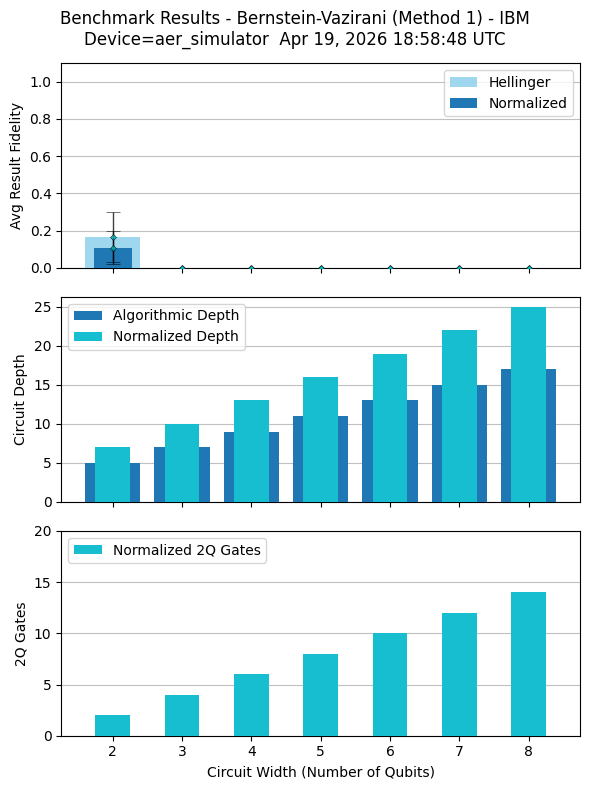

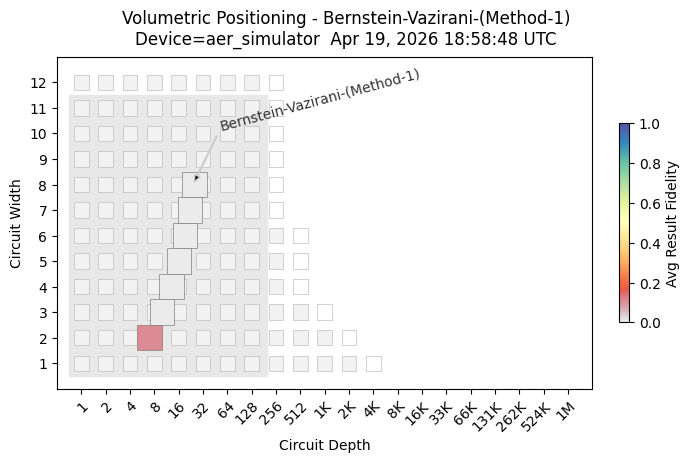

In [9]:
# Compute statistics for metrics.
metrics.aggregate_metrics()

# Set information for plot titles.
benchmark_name = "Bernstein-Vazirani"
provider_name = "IBM"
device_name = "aer_simulator"

# Set plot titles.
benchmark_title = f"{benchmark_name} (Method 1)"
subtitle = f"Benchmark Results - {benchmark_title} - {provider_name}"
metrics.circuit_metrics["subtitle"] = f"device = {device_name}"

# Determine which metrics to plot.
filters = ["fidelity", "hf_fidelity", "depth", "2q", "vbplot"]

# Plot the metrics.
metrics.plot_metrics(subtitle, filters=filters)